# Результаты экспериментов (n=220, RGB + NYPL pool)

Загружает все `data/eval/results/final/metrics_triad_*_n220.json` и строит:

- сводную таблицу 2 backbone × 4 template_mode (8 конфигов);
- bootstrap CI95 для CLIPScore_RU(archive);
- retrieval R@1 / R@5 / R@10 (text → image);
- **CLIPScore vs Retrieval trade-off** — главная находка волны;
- per-source subset breakdown (rgb anchor n=20 vs nypl pool n=200);
- качественные примеры.

In [20]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from scripts.eval_stats import bootstrap_ci, paired_bootstrap

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / 'data' / 'eval' / 'results' / 'final'
print('Results dir:', RESULTS_DIR)

Results dir: /Users/yanakhalitova/workspace/project-seminar/tsu-image-description/data/eval/results/final


## 1. Загрузка n=220 runs (2 backbone × 4 template_mode = 8 конфигов)

In [21]:
RUN_SPEC = [
    ('BLIP-base',  'full',             'baseline (full template)',           'metrics_triad_baseline_n220.json'),
    ('BLIP-base',  'full -theme-mood', 'E-16 (full -theme -mood)',           'metrics_triad_E-16_drop_theme_n220.json'),
    ('BLIP-base',  'minimal',          'E-16b (minimal)',                    'metrics_triad_E-16b_minimal_n220.json'),
    ('BLIP-base',  'caption_only',     'E-16c (caption only)',               'metrics_triad_E-16c_caption_only_n220.json'),
    ('BLIP-large', 'full',             'E-1 (full template)',                'metrics_triad_E-1_blip_large_n220.json'),
    ('BLIP-large', 'full -theme-mood', 'E-1+E-16 (full -theme -mood)',       'metrics_triad_E-1+16_blip_large_drop_theme_n220.json'),
    ('BLIP-large', 'minimal',          'E-1+E-16b (minimal)',                'metrics_triad_E-1+16b_blip_large_minimal_n220.json'),
    ('BLIP-large', 'caption_only',     'E-1+E-16c (caption only)',           'metrics_triad_E-1+16c_blip_large_caption_only_n220.json'),
]

runs = []
for backbone, tmpl, label, fname in RUN_SPEC:
    path = RESULTS_DIR / fname
    if not path.exists():
        print(f'[WARN] missing {fname}')
        continue
    runs.append({
        'backbone': backbone,
        'template': tmpl,
        'label':    label,
        'data':     json.loads(path.read_text(encoding='utf-8')),
    })

for r in runs:
    n = r['data']['summary']['num_examples']
    print(f"  {r['backbone']:11s}  {r['template']:18s}  {r['label']:38s}  n={n}")

  BLIP-base    full                baseline (full template)                n=220
  BLIP-base    full -theme-mood    E-16 (full -theme -mood)                n=220
  BLIP-base    minimal             E-16b (minimal)                         n=220
  BLIP-base    caption_only        E-16c (caption only)                    n=220
  BLIP-large   full                E-1 (full template)                     n=220
  BLIP-large   full -theme-mood    E-1+E-16 (full -theme -mood)            n=220
  BLIP-large   minimal             E-1+E-16b (minimal)                     n=220
  BLIP-large   caption_only        E-1+E-16c (caption only)                n=220


## 2. Сводная таблица — все 8 конфигов

Метрика: `CLIPScore_RU(archive)` через `M-CLIP/XLM-Roberta-Large-Vit-B-32`. Retrieval = text → image (поиск по русскому описанию).

In [22]:
def per_item_archive(r, source=None):
    return [
        it['scores']['CLIPScore_RU_archive_ru']
        for it in r['per_item']
        if it['scores'].get('CLIPScore_RU_archive_ru') is not None
        and (source is None or it.get('source') == source)
    ]

baseline_vals = per_item_archive(runs[0]['data'])

rows = []
for r in runs:
    s = r['data']['summary']
    vals = per_item_archive(r['data'])
    lo, hi = bootstrap_ci(vals, n_iter=1000, conf=0.95, seed=42)
    p = paired_bootstrap(baseline_vals, vals, n_iter=1000, seed=42) if r['label'] != runs[0]['label'] else None
    rows.append({
        'backbone':       r['backbone'],
        'template':       r['template'],
        'CLIPScore':      float(np.mean(vals)),
        'CI95':           f'[{lo:.3f}, {hi:.3f}]',
        'rgb (n=20)':     s['by_source']['rgb']['CLIPScore_RU_archive_ru'],
        'nypl (n=200)':   s['by_source']['nypl']['CLIPScore_RU_archive_ru'],
        'R@1':            s['retrieval']['t2i']['R@1'],
        'R@5':            s['retrieval']['t2i']['R@5'],
        'R@10':           s['retrieval']['t2i']['R@10'],
        'p vs baseline':  f'{p:.4f}' if p is not None else '—',
    })

table = pd.DataFrame(rows)
table.round(4)

,backbone,template,CLIPScore,CI95,rgb (n=20),nypl (n=200),R@1,R@5,R@10,p vs baseline
0,BLIP-base,full,0.2804,"[0.276, 0.284]",0.3254,0.2759,0.1591,0.3773,0.4636,—
1,BLIP-base,full -theme-mood,0.2865,"[0.282, 0.291]",0.3262,0.2825,0.1409,0.4045,0.5364,0.0000
2,BLIP-base,minimal,0.2663,"[0.262, 0.270]",0.3189,0.2610,0.1409,0.4273,0.5773,0.0000
3,BLIP-base,caption_only,0.2540,"[0.250, 0.258]",0.3012,0.2493,0.1455,0.4227,0.5727,0.0000
4,BLIP-large,full,0.2883,"[0.283, 0.294]",0.3313,0.2840,0.2136,0.4182,0.4909,0.0000
5,BLIP-large,full -theme-mood,0.2977,"[0.293, 0.303]",0.3341,0.2940,0.2409,0.4773,0.6045,0.0000
6,BLIP-large,minimal,0.2848,"[0.280, 0.290]",0.3224,0.2811,0.2636,0.5000,0.6000,0.0760
7,BLIP-large,caption_only,0.2735,"[0.268, 0.279]",0.3077,0.2701,0.2682,0.5045,0.6318,0.0110


## 3. CLIPScore_RU(archive) — grouped bar chart

По оси X — 4 template_mode. Цвет — backbone.

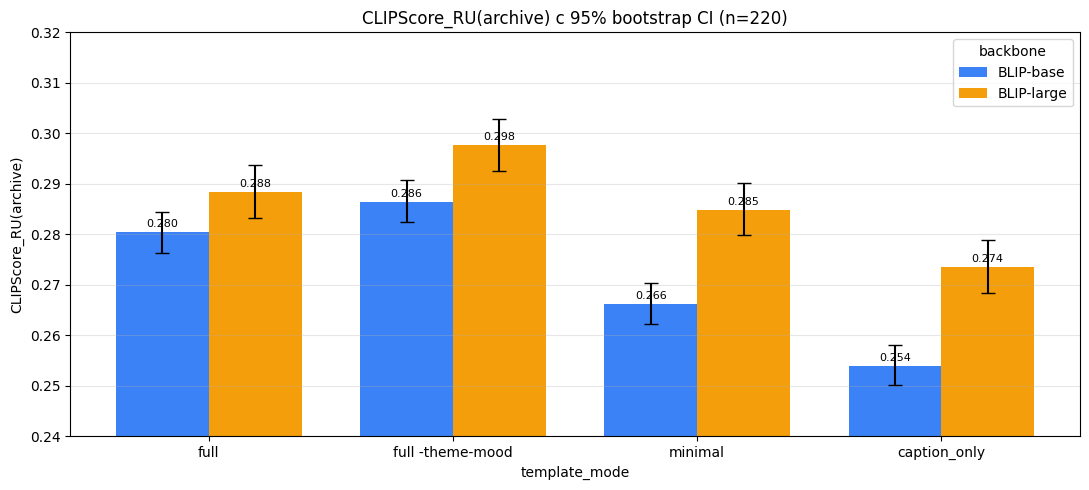

In [23]:
templates = ['full', 'full -theme-mood', 'minimal', 'caption_only']
backbones = ['BLIP-base', 'BLIP-large']
colors = {'BLIP-base': '#3b82f6', 'BLIP-large': '#f59e0b'}

def lookup(b, t):
    for r in runs:
        if r['backbone'] == b and r['template'] == t: return r
    return None

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(templates))
w = 0.38

for i, b in enumerate(backbones):
    means, errs_lo, errs_hi = [], [], []
    for t in templates:
        r = lookup(b, t)
        vals = per_item_archive(r['data'])
        m = float(np.mean(vals))
        lo, hi = bootstrap_ci(vals, n_iter=1000, conf=0.95, seed=42)
        means.append(m); errs_lo.append(m - lo); errs_hi.append(hi - m)
    offset = (i - 0.5) * w
    ax.bar(x + offset, means, w, yerr=[errs_lo, errs_hi], capsize=5,
           label=b, color=colors[b])
    for j, m in enumerate(means):
        ax.text(x[j] + offset, m + 0.001, f'{m:.3f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(templates)
ax.set_xlabel('template_mode')
ax.set_ylabel('CLIPScore_RU(archive)')
ax.set_title('CLIPScore_RU(archive) с 95% bootstrap CI (n=220)')
ax.legend(title='backbone')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.24, 0.32)
plt.tight_layout()
plt.show()

## 4. Retrieval R@1 / R@5 / R@10 (text → image, проксиметрика архивного поиска)

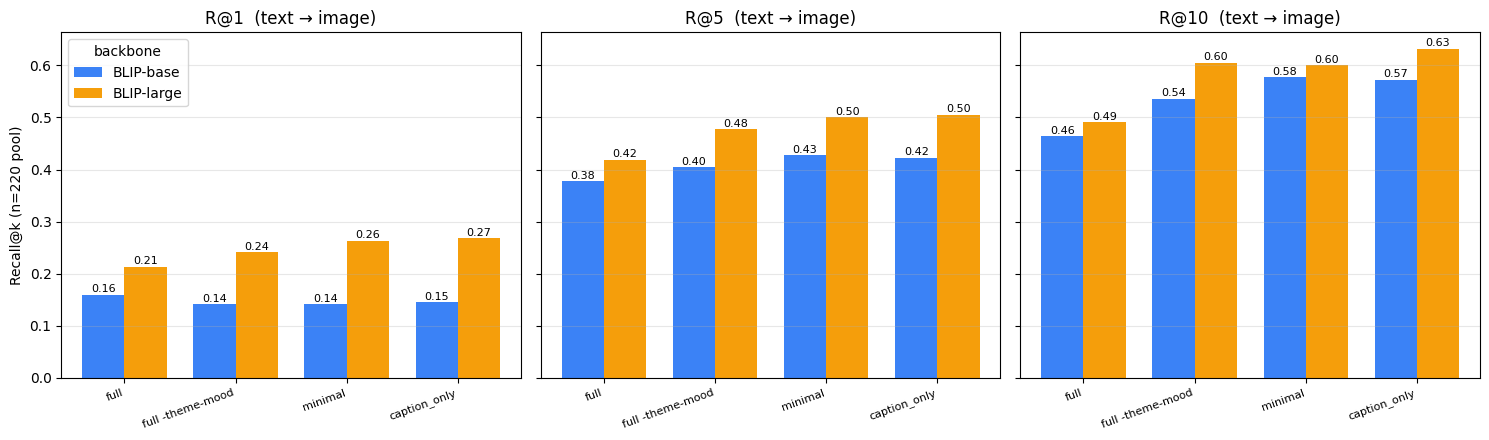

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, k_label in zip(axes, ['R@1', 'R@5', 'R@10']):
    for i, b in enumerate(backbones):
        vals = [lookup(b, t)['data']['summary']['retrieval']['t2i'][k_label] for t in templates]
        offset = (i - 0.5) * w
        ax.bar(x + offset, vals, w, label=b, color=colors[b])
        for j, v in enumerate(vals):
            ax.text(x[j] + offset, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(templates, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'{k_label}  (text → image)')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Recall@k (n=220 pool)')
axes[0].legend(title='backbone', loc='upper left')
plt.tight_layout()
plt.show()

## 5. **Главная находка: faithfulness vs searchability trade-off**

Scatter plot: каждая точка = одна конфигурация. X = CLIPScore_RU(archive) (faithfulness), Y = R@10 (searchability).

Идеально — справа сверху. Видно: упрощение шаблона сдвигает точки **из правого нижнего в левый верхний** — выигрыш по retrieval идёт за счёт CLIPScore. Это две метрики **оптимизируют разные вещи**:

- **CLIPScore** = средняя alignment между текстом и изображением. Шаблонные фразы помогают ("архивная открытка", "винтажная иллюстрация") — больше информации в тексте → выше score.
- **Retrieval** = relative ranking. Шаблон делает все описания похожими в эмбеддинг-пространстве → хуже различимы → ниже R@k.

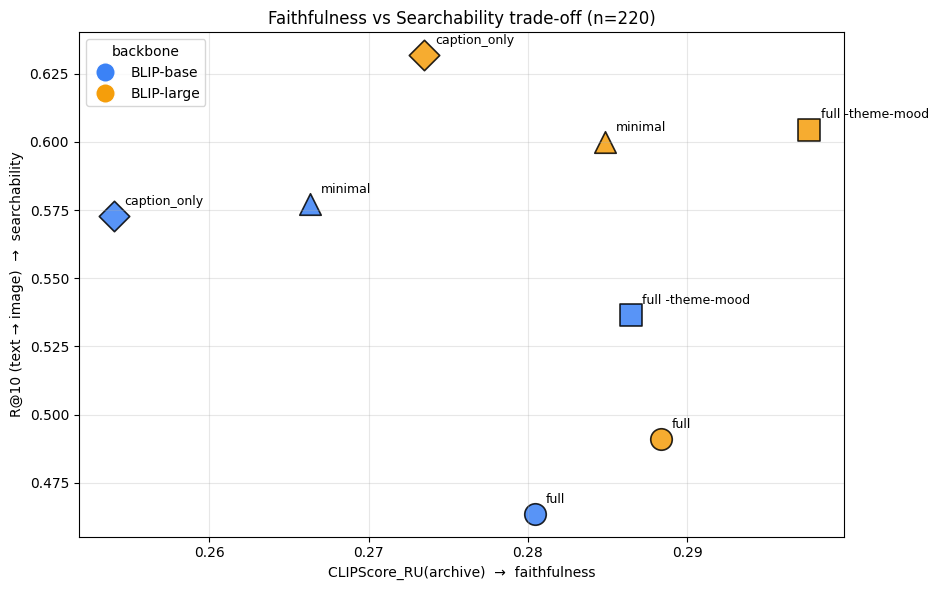

In [25]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(9.5, 6))
marker_for = {'full': 'o', 'full -theme-mood': 's', 'minimal': '^', 'caption_only': 'D'}

for r in runs:
    cs = float(np.mean(per_item_archive(r['data'])))
    r10 = r['data']['summary']['retrieval']['t2i']['R@10']
    ax.scatter(cs, r10, s=240, c=colors[r['backbone']], marker=marker_for[r['template']],
               edgecolors='black', linewidths=1.2, alpha=0.85)
    ax.annotate(r['template'], (cs, r10), xytext=(8, 8), textcoords='offset points', fontsize=9)

ax.set_xlabel('CLIPScore_RU(archive)  →  faithfulness')
ax.set_ylabel('R@10 (text → image)  →  searchability')
ax.set_title('Faithfulness vs Searchability trade-off (n=220)')
ax.grid(alpha=0.3)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['BLIP-base'],  markersize=14, label='BLIP-base'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['BLIP-large'], markersize=14, label='BLIP-large'),
]
ax.legend(handles=legend_elements, loc='upper left', title='backbone')
plt.tight_layout()
plt.show()

## 6. Per-source subset breakdown

Проверяем consistency: одинаковые ли тренды на rgb anchor (n=20) и nypl pool (n=200)?

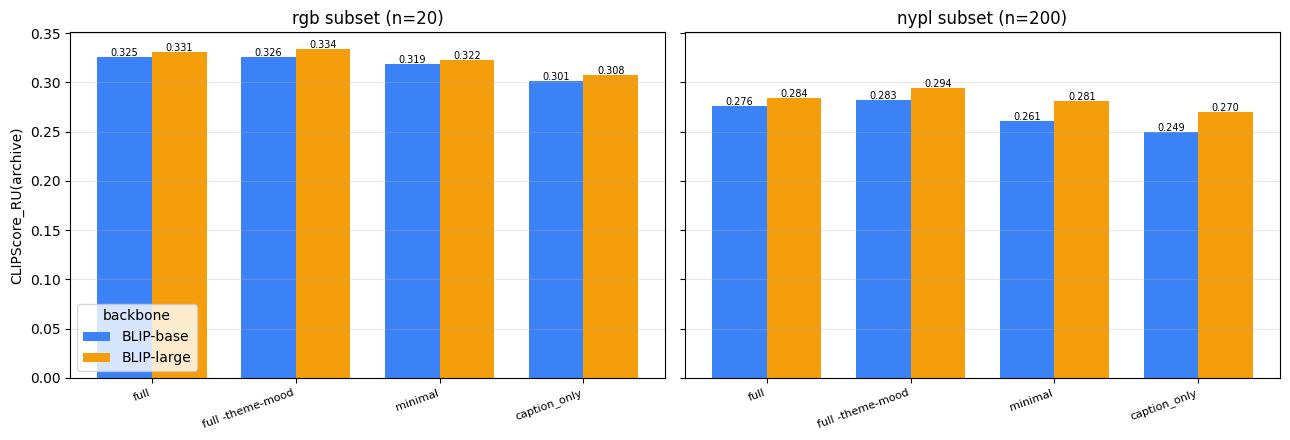

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, source in zip(axes, ['rgb', 'nypl']):
    for i, b in enumerate(backbones):
        vals = [lookup(b, t)['data']['summary']['by_source'][source]['CLIPScore_RU_archive_ru'] for t in templates]
        offset = (i - 0.5) * w
        ax.bar(x + offset, vals, w, label=b, color=colors[b])
        for j, v in enumerate(vals):
            ax.text(x[j] + offset, v + 0.001, f'{v:.3f}', ha='center', fontsize=7)
    n_label = 20 if source == 'rgb' else 200
    ax.set_xticks(x); ax.set_xticklabels(templates, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'{source} subset (n={n_label})')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('CLIPScore_RU(archive)')
axes[0].legend(title='backbone')
plt.tight_layout()
plt.show()

## 7. Качественные примеры — 3 rgb открытки, все 8 конфигов

Видно как **жёсткий шаблон** даёт длинный «catalog-style» текст, а **caption_only** — голый перевод BLIP.

In [27]:
baseline_items = runs[0]['data']['per_item']

for idx in range(3):
    print(f"=== {Path(baseline_items[idx]['image_path']).name} ===")
    print(f"  reference: {baseline_items[idx]['reference_ru']}")
    for r in runs:
        it = r['data']['per_item'][idx]
        score = it['scores']['CLIPScore_RU_archive_ru']
        print(f"  [{score:.3f}] {r['backbone']:11s} / {r['template']:18s}: {it['archive_ru']}")
    print()

=== postcard_1.jpg ===
  reference: Сосновый лес
  [0.326] BLIP-base   / full              : Фотография в стиле черно-белая фотография. На изображении: черно-белое фото деревьев в лесу. Предположительно, это сцена природы. Общее настроение изображения можно охарактеризовать как ностальгическое.
  [0.320] BLIP-base   / full -theme-mood  : Фотография в стиле черно-белая фотография. На изображении: черно-белое фото деревьев в лесу.
  [0.340] BLIP-base   / minimal           : На изображении: черно-белое фото деревьев в лесу.
  [0.323] BLIP-base   / caption_only      : черно-белое фото деревьев в лесу
  [0.324] BLIP-large  / full              : Фотография в стиле черно-белая фотография. На изображении: Есть черно-белая фотография леса с деревьями.. Предположительно, это сцена природы. Общее настроение изображения можно охарактеризовать как ностальгическое.
  [0.322] BLIP-large  / full -theme-mood  : Фотография в стиле черно-белая фотография. На изображении: Есть черно-белая фотография леса 